In [3]:
import pandas as pd
import os

# Paths
KAGGLE_BASE = "/Volumes/Samsung_T5/respiratory_classification_project/kaggle-data"
COSWARA_BASE = "/Volumes/Samsung_T5/respiratory_classification_project/coswara-data"

df = pd.read_csv("/Volumes/Samsung_T5/respiratory_classification_project/final_combined_dataset.csv")

def fix_path(row):
    pid = row["id"]
    if pd.isna(pid):
        return None, None

    # Check if it's a Kaggle entry (cough.wav)
    kaggle_cough = f"{KAGGLE_BASE}/{pid}/cough.wav"
    kaggle_vowel = f"{KAGGLE_BASE}/{pid}/vowel.wav"
    if os.path.exists(kaggle_cough):
        return kaggle_cough, kaggle_vowel

    # Otherwise search Coswara date folders (cough-heavy.wav)
    for date_folder in os.listdir(COSWARA_BASE):
        coswara_cough = f"{COSWARA_BASE}/{date_folder}/{pid}/cough-heavy.wav"
        coswara_vowel = f"{COSWARA_BASE}/{date_folder}/{pid}/vowel-o.wav"
        if os.path.exists(coswara_cough):
            return coswara_cough, coswara_vowel

    return None, None

print("Building paths... (this may take a minute)")
df[["cough_path", "vowel_path"]] = df.apply(
    lambda row: pd.Series(fix_path(row)), axis=1
)

# Drop rows where files not found
df_clean = df.dropna(subset=["cough_path", "vowel_path"])

print(f"\nTotal rows: {len(df)}")
print(f"Rows with files found: {len(df_clean)}")
print(f"\nDisease distribution:")
print(df_clean["disease"].value_counts())

Building paths... (this may take a minute)

Total rows: 3630
Rows with files found: 3630

Disease distribution:
disease
healthy    1716
covid       545
other       509
asthma      354
copd        168
Name: count, dtype: int64


In [4]:
import pandas as pd
import os

# Paths
KAGGLE_BASE = "/Volumes/Samsung_T5/respiratory_classification_project/kaggle-data"
COSWARA_BASE = "/Volumes/Samsung_T5/respiratory_classification_project/coswara-data"

df = pd.read_csv("/Volumes/Samsung_T5/respiratory_classification_project/final_combined_dataset.csv")

def fix_path(row):
    pid = row["id"]
    if pd.isna(pid):
        return None, None

    # Check if it's a Kaggle entry (cough.wav)
    kaggle_cough = f"{KAGGLE_BASE}/{pid}/cough.wav"
    kaggle_vowel = f"{KAGGLE_BASE}/{pid}/vowel.wav"
    if os.path.exists(kaggle_cough):
        return kaggle_cough, kaggle_vowel

    # Otherwise search Coswara date folders (cough-heavy.wav)
    for date_folder in os.listdir(COSWARA_BASE):
        coswara_cough = f"{COSWARA_BASE}/{date_folder}/{pid}/cough-heavy.wav"
        coswara_vowel = f"{COSWARA_BASE}/{date_folder}/{pid}/vowel-o.wav"
        if os.path.exists(coswara_cough):
            return coswara_cough, coswara_vowel

    return None, None

print("Building paths... (this may take a minute)")
df[["cough_path", "vowel_path"]] = df.apply(
    lambda row: pd.Series(fix_path(row)), axis=1
)

# Drop rows where files not found
df_clean = df.dropna(subset=["cough_path", "vowel_path"])

print(f"\nTotal rows: {len(df)}")
print(f"Rows with files found: {len(df_clean)}")
print(f"\nDisease distribution:")
print(df_clean["disease"].value_counts())

Building paths... (this may take a minute)

Total rows: 3630
Rows with files found: 3630

Disease distribution:
disease
healthy    1716
covid       545
other       509
asthma      354
copd        168
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import os

In [6]:
# Input
INPUT_CSV       =  df 
OUTPUT_DIR = "/Volumes/Samsung_T5/respiratory_classification_project/segmented"
OUTPUT_CSV = "/Volumes/Samsung_T5/respiratory_classification_project/dataset_segmented.csv"
# Audio settings
SR              = 22050     # sample rate — standard for audio ML
FRAME_LEN       = 512       # ~23ms window for energy calculation
HOP_LEN         = 128       # ~6ms step between frames
 
# VAD thresholds (from energy envelope plots)
KAGGLE_THRESH   = 0.02      # works for kaggle — clean recordings
COSWARA_THRESH  = 0.05      # slightly higher for coswara — more background noise
 
# Cough segment duration limits
COUGH_MIN_SEC   = 0.3       # anything shorter is noise/click, skip it
COUGH_MAX_SEC   = 3.0       # anything longer is not a single cough, skip it
 
# Vowel segment duration limits
VOWEL_MIN_SEC   = 1.0       # vowel must be at least 1 second
VOWEL_MAX_SEC   = 6.0       # vowel rarely exceeds 6 seconds
 
# Padding around each detected segment
PAD_SEC         = 0.05      # 50ms padding to capture attack/release

In [7]:
def detect_events(y, sr, thresh):
    """
    Given an audio signal y:
    1. Compute RMS energy per frame
    2. Normalize 0-1
    3. Apply threshold to get binary VAD mask
    4. Find contiguous active regions (events)
    Returns list of (start_frame, end_frame) tuples
    """
    # Compute RMS energy
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]
 
    # Normalize between 0 and 1
    rms_norm = rms / (rms.max() + 1e-9)
 
    # Binary mask: True = sound, False = silence
    active = rms_norm > thresh
 
    # Find contiguous active regions
    events = []
    in_event = False
    start = 0
    for i, a in enumerate(active):
        if a and not in_event:        # silence → sound: mark start
            start = i
            in_event = True
        elif not a and in_event:      # sound → silence: mark end
            events.append((start, i))
            in_event = False
    if in_event:                      # handle sound right at end of file
        events.append((start, len(active) - 1))
 
    return events

In [8]:
def segment_audio(audio_path, patient_id, disease, audio_type, output_dir):
    """
    Loads one audio file, runs VAD, saves valid segments.
 
    audio_type: "cough" or "vowel"
    Returns list of dicts (one per saved segment)
    """
    segments = []
 
    # Detect which dataset this file is from
    is_coswara = "coswara-data" in audio_path
    thresh     = COSWARA_THRESH if is_coswara else KAGGLE_THRESH
    source     = "coswara" if is_coswara else "kaggle"
 
    # Set duration limits based on audio type
    if audio_type == "cough":
        min_sec = COUGH_MIN_SEC
        max_sec = COUGH_MAX_SEC
    else:  # vowel — one long sustained sound, wider range
        min_sec = VOWEL_MIN_SEC
        max_sec = VOWEL_MAX_SEC
 
    # Load audio
    try:
        y, sr = librosa.load(audio_path, sr=SR, mono=True)
    except Exception as e:
        print(f"  ❌ Could not load {audio_path}: {e}")
        return segments
 
    # Detect events using VAD
    events    = detect_events(y, sr, thresh)
    pad_frames = int(PAD_SEC * SR / HOP_LEN)
 
    # Loop through each detected event
    for idx, (s, e) in enumerate(events):
 
        # Add padding around event
        s_pad = max(0, s - pad_frames)
        e_pad = min(len(librosa.feature.rms(
            y=y, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]) - 1,
            e + pad_frames)
 
        # Convert frames to samples
        start_sample = s_pad * HOP_LEN
        end_sample   = e_pad * HOP_LEN
        duration     = (end_sample - start_sample) / SR
 
        # Skip segments outside duration range
        if duration < min_sec or duration > max_sec:
            continue
 
        # Extract segment
        segment  = y[start_sample:end_sample]
 
        # Save segment as wav file
        filename = f"{patient_id}_{audio_type}_{idx}.wav"
        out_path = os.path.join(output_dir, filename)
        sf.write(out_path, segment, SR)
 
        segments.append({
            "patient_id"   : patient_id,
            "disease"      : disease,
            "audio_type"   : audio_type,   # "cough" or "vowel"
            "segment_path" : out_path,
            "duration_sec" : round(duration, 3),
            "segment_idx"  : idx,
            "source"       : source        # "kaggle" or "coswara"
        })
 
    return segments

In [9]:
def segment_audio(audio_path, patient_id, disease, audio_type, output_dir):
    """
    Loads one audio file, runs VAD, saves valid segments.
 
    audio_type: "cough" or "vowel"
    Returns list of dicts (one per saved segment)
    """
    segments = []
 
    # Detect which dataset this file is from
    is_coswara = "coswara-data" in audio_path
    thresh     = COSWARA_THRESH if is_coswara else KAGGLE_THRESH
    source     = "coswara" if is_coswara else "kaggle"
 
    # Set duration limits based on audio type
    if audio_type == "cough":
        min_sec = COUGH_MIN_SEC
        max_sec = COUGH_MAX_SEC
    else:  # vowel — one long sustained sound, wider range
        min_sec = VOWEL_MIN_SEC
        max_sec = VOWEL_MAX_SEC
 
    # Load audio
    try:
        y, sr = librosa.load(audio_path, sr=SR, mono=True)
    except Exception as e:
        print(f"  ❌ Could not load {audio_path}: {e}")
        return segments
 
    # Detect events using VAD
    events    = detect_events(y, sr, thresh)
    pad_frames = int(PAD_SEC * SR / HOP_LEN)
 
    # Loop through each detected event
    for idx, (s, e) in enumerate(events):
 
        # Add padding around event
        s_pad = max(0, s - pad_frames)
        e_pad = min(len(librosa.feature.rms(
            y=y, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]) - 1,
            e + pad_frames)
 
        # Convert frames to samples
        start_sample = s_pad * HOP_LEN
        end_sample   = e_pad * HOP_LEN
        duration     = (end_sample - start_sample) / SR
 
        # Skip segments outside duration range
        if duration < min_sec or duration > max_sec:
            continue
 
        # Extract segment
        segment  = y[start_sample:end_sample]
 
        # Save segment as wav file
        filename = f"{patient_id}_{audio_type}_{idx}.wav"
        out_path = os.path.join(output_dir, filename)
        sf.write(out_path, segment, SR)
 
        segments.append({
            "patient_id"   : patient_id,
            "disease"      : disease,
            "audio_type"   : audio_type,   # "cough" or "vowel"
            "segment_path" : out_path,
            "duration_sec" : round(duration, 3),
            "segment_idx"  : idx,
            "source"       : source        # "kaggle" or "coswara"
        })
 
    return segments

In [10]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
all_segments = []
failed       = 0
 
print(f"Processing {len(df)} recordings...\n")
 
for i, row in df.iterrows():
    pid     = row["id"]
    disease = row["disease"]
 
    cough_path = row["cough_path"]
    vowel_path = row["vowel_path"]
 
    # Skip rows with missing disease label
    if pd.isna(disease):
        failed += 1
        continue
 
    # --- Process cough ---
    if pd.notna(cough_path) and os.path.exists(str(cough_path)):
        cough_segs = segment_audio(cough_path, pid, disease, "cough", OUTPUT_DIR)
        all_segments.extend(cough_segs)
    else:
        failed += 1
 
    # --- Process vowel ---
    if pd.notna(vowel_path) and os.path.exists(str(vowel_path)):
        vowel_segs = segment_audio(vowel_path, pid, disease, "vowel", OUTPUT_DIR)
        all_segments.extend(vowel_segs)
 
    # Progress update every 100 patients
    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(df)}] Segments so far: {len(all_segments)}")


Processing 3630 recordings...

  [100/3630] Segments so far: 1511
  [200/3630] Segments so far: 2860
  [300/3630] Segments so far: 4177
  [400/3630] Segments so far: 5463
  [500/3630] Segments so far: 6604
  [900/3630] Segments so far: 7266
  [1000/3630] Segments so far: 7588
  [1100/3630] Segments so far: 7918
  [1200/3630] Segments so far: 8232
  [1300/3630] Segments so far: 8573
  [1400/3630] Segments so far: 8875
  [1500/3630] Segments so far: 9206
  [1600/3630] Segments so far: 9607
  [1700/3630] Segments so far: 10054
  [1800/3630] Segments so far: 10534
  [1900/3630] Segments so far: 10974
  [2000/3630] Segments so far: 11355
  [2100/3630] Segments so far: 11747
  [2200/3630] Segments so far: 12174
  [2300/3630] Segments so far: 12550
  [2400/3630] Segments so far: 12969
  [2500/3630] Segments so far: 13373
  [2600/3630] Segments so far: 13725
  [2700/3630] Segments so far: 14208
  [2800/3630] Segments so far: 14506
  [2900/3630] Segments so far: 14909
  [3000/3630] Segments so 

In [11]:
df_seg = pd.DataFrame(all_segments)
df_seg.to_csv(OUTPUT_CSV, index=False)
 
print(f"\n✅ Done!")
print(f"   Total patients       : {len(df)}")
print(f"   Failed / skipped     : {failed}")
print(f"   Total segments saved : {len(df_seg)}")
print(f"   Avg per patient      : {len(df_seg) / max(len(df)-failed, 1):.1f}")
 
print(f"\nDisease distribution:")
print(df_seg["disease"].value_counts())
 
print(f"\nAudio type breakdown:")
print(df_seg["audio_type"].value_counts())
 
print(f"\nSource breakdown:")
print(df_seg["source"].value_counts())
 
print(f"\nSample output:")
print(df_seg.head(3).to_string())


✅ Done!
   Total patients       : 3630
   Failed / skipped     : 338
   Total segments saved : 17771
   Avg per patient      : 5.4

Disease distribution:
disease
healthy    8056
asthma     3694
copd       2248
covid      1926
other      1847
Name: count, dtype: int64

Audio type breakdown:
audio_type
cough    15205
vowel     2566
Name: count, dtype: int64

Source breakdown:
source
coswara    10571
kaggle      7200
Name: count, dtype: int64

Sample output:
      patient_id disease audio_type                                                                                segment_path  duration_sec  segment_idx  source
0  b87ea0dd760fa  asthma      cough  /Volumes/Samsung_T5/respiratory_classification_project/segmented/b87ea0dd760fa_cough_0.wav         0.302            0  kaggle
1  b87ea0dd760fa  asthma      cough  /Volumes/Samsung_T5/respiratory_classification_project/segmented/b87ea0dd760fa_cough_1.wav         0.673            1  kaggle
2  b87ea0dd760fa  asthma      cough  /Volumes/Sams

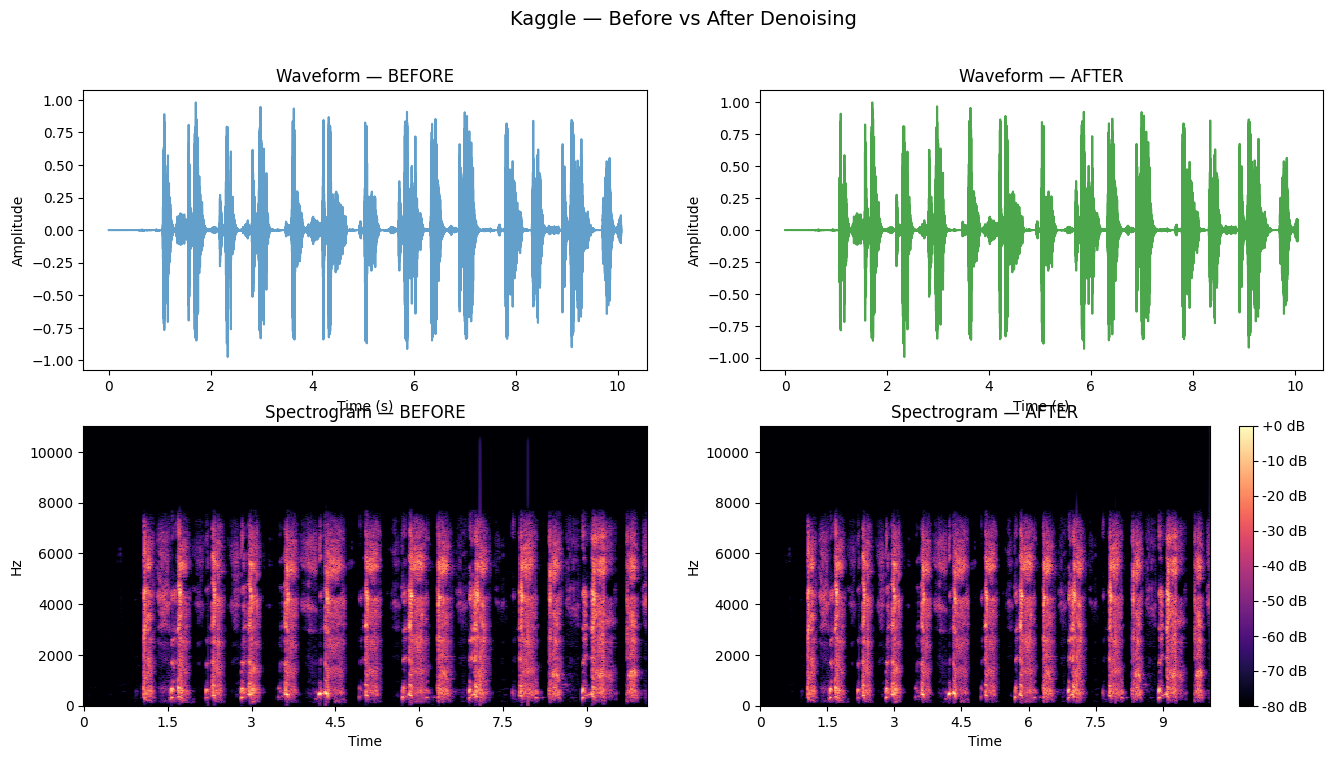

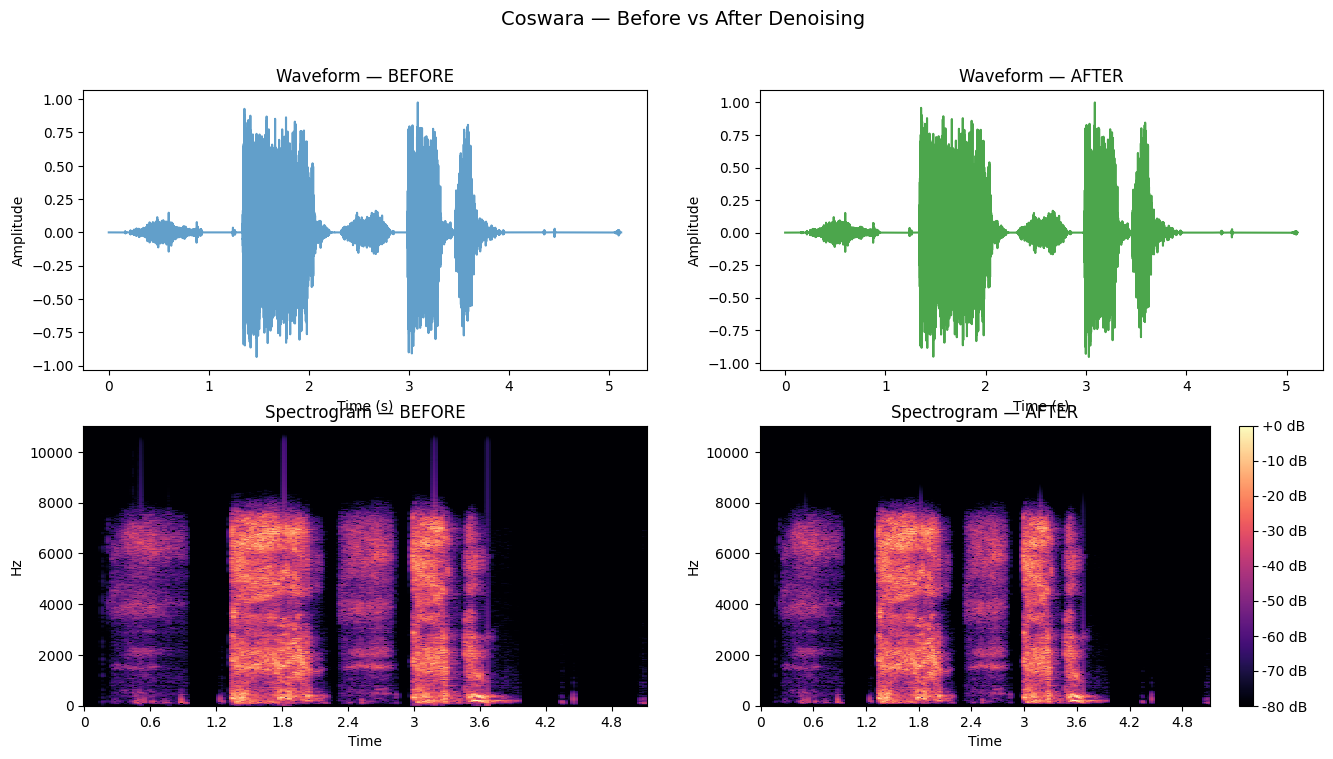

In [18]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt

SR = 22050

def denoise_audio(y, sr):
    y = y - np.mean(y)
    b, a = butter(4, 100 / (sr / 2), btype='high')
    y = filtfilt(b, a, y)
    b, a = butter(4, 8000 / (sr / 2), btype='low')
    y = filtfilt(b, a, y)
    S = librosa.stft(y)
    magnitude = np.abs(S)
    phase = np.angle(S)
    noise_estimate = np.mean(magnitude[:, :10], axis=1, keepdims=True)
    magnitude_clean = np.maximum(magnitude - noise_estimate, 0)
    S_clean = magnitude_clean * np.exp(1j * phase)
    y_clean = librosa.istft(S_clean)
    y_clean = y_clean / (np.max(np.abs(y_clean)) + 1e-9)
    return y_clean


kaggle_path  = df[df["disease"] == "asthma"]["cough_path"].iloc[0]
coswara_path = df[df["disease"] == "covid"]["cough_path"].iloc[0]

for name, path in [("Kaggle", kaggle_path), ("Coswara", coswara_path)]:
    y_raw, sr = librosa.load(path, sr=SR, mono=True)
    y_clean   = denoise_audio(y_raw, sr)

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(f"{name} — Before vs After Denoising", fontsize=14)

    # --- Waveform before ---
    axes[0, 0].plot(np.linspace(0, len(y_raw)/sr, len(y_raw)), y_raw, alpha=0.7)
    axes[0, 0].set_title("Waveform — BEFORE")
    axes[0, 0].set_xlabel("Time (s)")
    axes[0, 0].set_ylabel("Amplitude")

    # --- Waveform after ---
    axes[0, 1].plot(np.linspace(0, len(y_clean)/sr, len(y_clean)), y_clean, alpha=0.7, color='green')
    axes[0, 1].set_title("Waveform — AFTER")
    axes[0, 1].set_xlabel("Time (s)")
    axes[0, 1].set_ylabel("Amplitude")

    # --- Spectrogram before ---
    D_raw = librosa.amplitude_to_db(np.abs(librosa.stft(y_raw)), ref=np.max)
    librosa.display.specshow(D_raw, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 0])
    axes[1, 0].set_title("Spectrogram — BEFORE")
    axes[1, 0].set_ylim(0, 11025)

    # --- Spectrogram after ---
    D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
    img = librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 1])
    axes[1, 1].set_title("Spectrogram — AFTER")
    axes[1, 1].set_ylim(0, 11025)
    fig.colorbar(img, ax=axes[1, 1], format='%+2.0f dB')

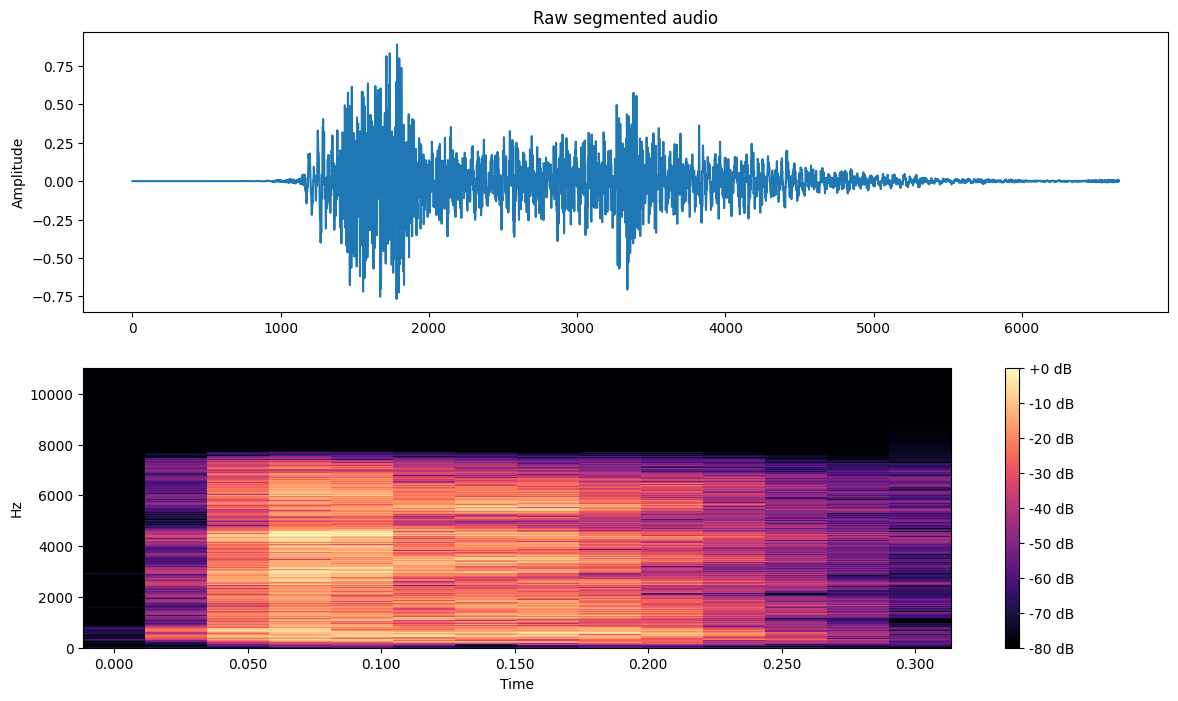

In [15]:

import librosa
import matplotlib.pyplot as plt 
path = "/Volumes/Samsung_T5/respiratory_classification_project/segmented/b87ea0dd760fa_cough_0.wav"

y, sr = librosa.load(path, sr=22050)

plt.figure(figsize=(14, 8))

# Plot 1: raw waveform
plt.subplot(2, 1, 1)
plt.plot(y)
plt.title("Raw segmented audio")
plt.ylabel("Amplitude")

# Plot 2: frequency spectrum
plt.subplot(2, 1, 2)
D = np.abs(librosa.stft(y))
DB = librosa.amplitude_to_db(D, ref=np.max)
librosa.display.specshow(DB, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.show()